In [1]:
# 1. 파이썬 코드에서 Matplotlib 폰트 설정
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from datetime import timedelta
from itertools import combinations
from collections import Counter

# 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

print("한글 폰트 설정이 완료되었습니다.")

# 3. 데이터 로드 및 통합 (모든 문제 풀이의 시작점)
try:
    orders_df = pd.read_csv('../data/orders.csv')
    payments_df = pd.read_csv('../data/payments.csv')
    products_df = pd.read_csv('../data/products.csv')
    shipping_df = pd.read_csv('../data/shipping.csv')
    customers_df = pd.read_csv('../data/customers.csv')

    # 모든 데이터프레임 병합
    df = pd.merge(orders_df, payments_df, on='order_id', how='left')
    df = pd.merge(df, products_df, on='product_id', how='left')
    df = pd.merge(df, customers_df, on='customer_id', how='left')
    df = pd.merge(df, shipping_df, on='order_id', how='left')

    # 데이터 전처리
    date_cols = ['order_date', 'payment_date', 'join_date', 'shipping_start_date', 'shipping_end_date']
    for col in date_cols:
        df[col] = pd.to_datetime(df[col], errors='coerce')
    df['total_sales'] = df['quantity'] * df['price']
    
    print("데이터 로드 및 통합이 완료되었습니다.")

except FileNotFoundError as e:
    print(f"파일을 찾을 수 없습니다: {e}")


한글 폰트 설정이 완료되었습니다.
데이터 로드 및 통합이 완료되었습니다.


In [2]:
# 문제 6: 성별과 연령대를 조합하여 (예: '20대 남성'), 각 그룹의 평균 주문액(AOV)을 비교하세요.
# 시각화: 히트맵

# 비즈니스 목적: 보다 세분화된 고객 그룹(세그먼트)의 특징을 분석하고, 특정 그룹에 대한 타겟 마케팅 전략의 효과를 극대화합니다.

# 출력 결과를 보고 코딩하세요

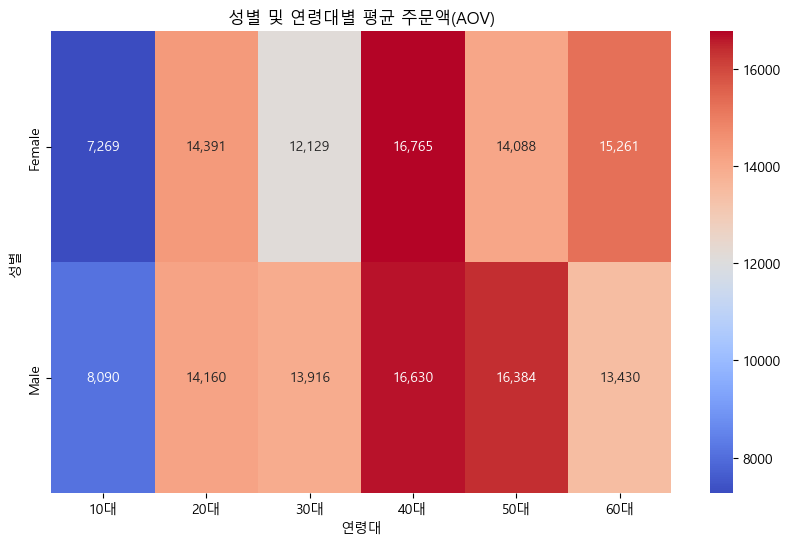



C:\Users\TJ\AppData\Local\Temp\ipykernel_1016\3546222846.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  aov = df.groupby(['gender', 'age_group'])['total_sales'].mean().reset_index().sort_values(['gender', 'age_group'])
C:\Users\TJ\AppData\Local\Temp\ipykernel_1016\3546222846.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_aov = aov.pivot_table(
C:\Users\TJ\AppData\Local\Temp\ipykernel_1016\3546222846.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot = pivot_aov.applymap(lambda x: f"{x:,.0f}")


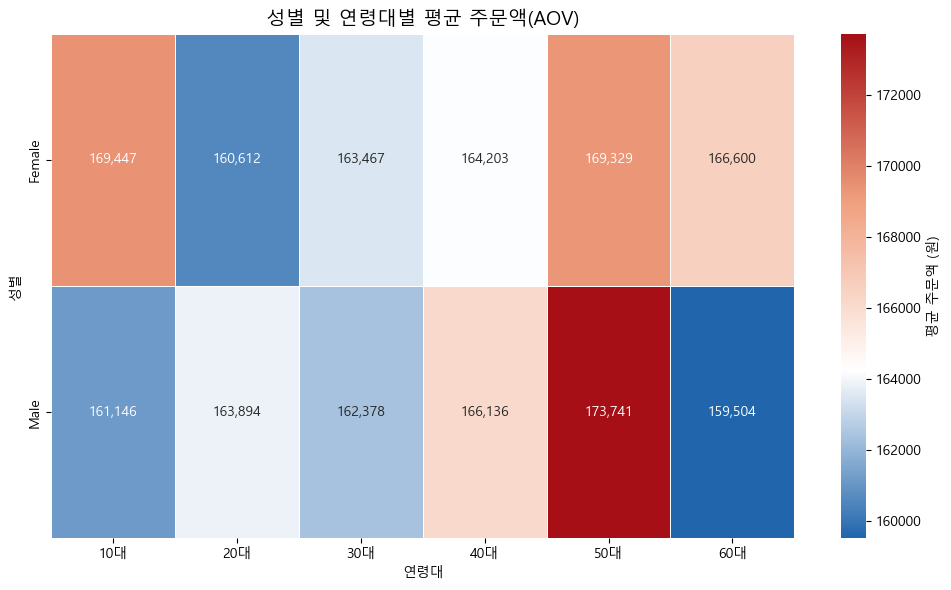

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors

bins = [10, 19, 29, 39, 49, 59, 69]
labels = ['10대', '20대', '30대', '40대', '50대', '60대']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels)


# 1️⃣ 성별 + 연령대별 평균 주문액(AOV) 계산 및 정렬
aov = df.groupby(['gender', 'age_group'])['total_sales'].mean().reset_index().sort_values(['gender', 'age_group'])

# 2️⃣ 피벗 테이블 생성 (축 교체!)
pivot_aov = aov.pivot_table(
    index='gender',     # 행: 성별
    columns='age_group',# 열: 연령대
    values='total_sales',
    aggfunc='mean'
)

# 3️⃣ 색상 설정 (연속형으로 자연스럽게 이어지게)
# 파랑 → 흰색 → 연한 주황 → 빨강 계열 그라데이션
colors = ['#2166ac', '#ffffff', '#f0a07e', '#a50f15']
cmap = mcolors.LinearSegmentedColormap.from_list("custom_gradient", colors)

# 4️⃣ 연속형 범위 설정 (데이터 최소/최대 자동 인식)
norm = mcolors.Normalize(vmin=pivot_aov.min().min(), vmax=pivot_aov.max().max())

# 5️⃣ 표시용 숫자 포맷
annot = pivot_aov.applymap(lambda x: f"{x:,.0f}")

# 6️⃣ 히트맵 시각화
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_aov,
    annot=annot,
    fmt='',
    cmap=cmap,
    norm=norm,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': '평균 주문액 (원)'}
)

plt.title('성별 및 연령대별 평균 주문액(AOV)', fontsize=14)
plt.xlabel('연령대')
plt.ylabel('성별')
plt.tight_layout()
plt.show()
